In [2]:

import os
print(os.getcwd())
import sys
sys.path.append('/media/chronos/Storage/natalie/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL')


/media/chronos/Storage/natalie/HW/DEEP_LEARN_PROJECT


In [5]:
input_file = 'list.txt'     # Change this to your input filename
output_file = 'fsm_t1_images.txt'       # New filtered list

with open(input_file, 'r') as f:
    lines = f.readlines()

# Filter lines containing 'fsm_t1'
filtered_lines = [line for line in lines if 'fsm_t1' in line]

# Save filtered lines to output file
with open(output_file, 'w') as f:
    f.writelines(filtered_lines)

print(f"Saved {len(filtered_lines)} lines to {output_file}")


Saved 38 lines to fsm_t1_images.txt


In [6]:
import numpy as np

data = np.load("/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/converted_npz/fsm_t1_50ww.npz")

# List all arrays stored in the .npz file
print(data.files)

# For each array (assuming 'image' is a key, or use the actual key shown in your file)
arr = data["vol"]  # or replace "image" with the actual key
print("Shape:", arr.shape)
print("Number of elements:", arr.size)
print("Data type:", arr.dtype)

['vol', 'seg']
Shape: (256, 256, 256)
Number of elements: 16777216
Data type: float32


training

In [3]:
%run -i voxelmorph_extension_DL/scripts/train.py --img-list 'fsmt1_short.txt'  --epochs 1

Epoch 1/1 - 0.4876 sec/step - loss: 2.4569e+03  (2.4569e+03, 6.0112e-04)


registration

In [8]:
%run -i voxelmorph_extension_DL/scripts/register.py --moving converted_npz/fsm_t1_50ww.npz --fixed converted_npz/fsm_t1_50ww.npz --moved warped.nii.gz --model models/0001.pt --gpu 0

(256, 256, 256)


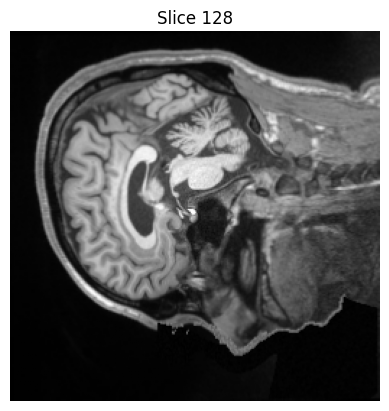

(256, 256, 256)


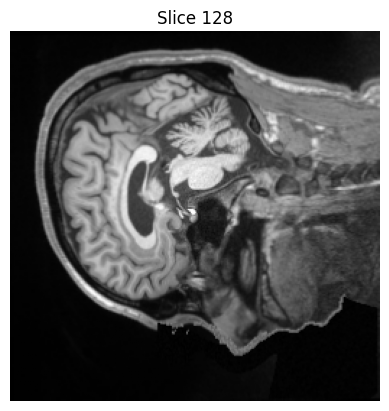

In [14]:
import nibabel as nib

# Replace with your file path
nii_img = nib.load('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/warped.nii.gz')
nii_data = nii_img.get_fdata()  # Returns a NumPy array
print(nii_data.shape)  # E.g., (128, 128, 96)

import matplotlib.pyplot as plt

# Visualize the middle axial slice
mid_slice = nii_data.shape[2] // 2
plt.imshow(nii_data[:, :, mid_slice], cmap='gray')
plt.title(f'Slice {mid_slice}')
plt.axis('off')
plt.show()


##################

# Replace with your file path
nii_img = np.load('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/converted_npz/fsm_t1_50ww.npz')
nii_img = nii_img["vol"]
print(nii_data.shape)  # E.g., (128, 128, 96)

import matplotlib.pyplot as plt

# Visualize the middle axial slice
mid_slice = nii_data.shape[2] // 2
plt.imshow(nii_data[:, :, mid_slice], cmap='gray')
plt.title(f'Slice {mid_slice}')
plt.axis('off')
plt.show()

inference

In [9]:
%./scripts/tf/test.py --model model.h5 --atlas atlas.npz --scans scan01.npz scan02.npz scan03.npz --labels labels.npz

UsageError: Line magic function `%./scripts/tf/test.py` not found.


Epoch 1/1 - 0.4885 sec/step - loss: 2.3406e+03  (2.3406e+03, 5.4073e-04)
